# Algorithmic Trading — Exam Toolkit
### Post-Trade Analysis (HW6) · Pre-Trade Analysis (HW7) · Trade Strategy Optimization (HW8)

---

**How to use this notebook:**
1. Run **Section 0** first — it loads all libraries and defines every function you'll need.
2. Jump to whichever section matches your problem type.
3. Change the parameter values in any `# ✏️ CHANGE THESE` block, then run the cell.
4. Answers print automatically. Graphs (HW8) render inline.

> **Tip:** Press `Shift + Enter` to run a cell and move to the next one.

## Table of Contents

| Section | Topic | Key Formulas |
|---------|-------|--------------|
| **0** | Setup & All Functions | — |
| **1** | Implementation Shortfall (IS) | Paper Return, Portfolio Return, Delay/Exec/Opp/Fixed Cost |
| **2** | Arrival Cost | `side × (Pavg − P0) / P0 × 10000` |
| **3** | VWAP Slippage | `side × (Pavg − VWAP) / VWAP × 10000` |
| **4** | Benchmark Cost | `side × (Pavg − Benchmark) / Benchmark × 10000` |
| **5** | Value-Add & Z-Score | `Value-Add = Expected MI − Actual Arrival Cost` |
| **6** | RPM (Relative Performance Measure) | Volume-weighted percentile |
| **7** | Pre-Trade: MI, TR, PA, POV/Time | Kissell market impact model |
| **8** | Expected Cost & Expected Price | `MI + PA`, price adjustment |
| **9** | Max Shares / Time / POV solvers | Root-finding with `brentq` |
| **10** | Traders Dilemma Optimization | `min(MI + λ·TR)` |
| **11** | Minimize Cost Optimization | `min(MI + PA)` |
| **12** | Price Improvement Optimization | `max t-value = (Bid − MI) / TR` |
| **13** | Efficient Trading Frontier | Sweep λ values |
| **14** | Market Impact Constraint | Max shares under MI cap |

---
## Section 0 — Setup & Function Definitions

**Run this cell first every time you open the notebook.** It defines all the functions used throughout.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import minimize, brentq

pd.options.display.float_format = '{:,.4f}'.format

# ═══════════════════════════════════════════════════════
# MI MODEL PARAMETERS (Kissell Research Group)
# These are constants fitted from market data.
# ═══════════════════════════════════════════════════════
a1 = 883.58722
a2 = 0.35408
a3 = 0.755684
a4 = 0.826155
b1 = 0.963532

# ═══════════════════════════════════════════════════════
# POST-TRADE FUNCTIONS (HW6)
# ═══════════════════════════════════════════════════════

def paper_return(side, S, Pd, Pn):
    """
    The hypothetical profit if ALL shares were bought/sold
    at the decision price and sold/bought at the final price.
    
    side : +1 for Buy, -1 for Sell
    S    : total shares intended (order size)
    Pd   : decision price (price when PM decided to trade)
    Pn   : final closing price at end of trading horizon
    """
    return side * S * (Pn - Pd)


def portfolio_return(side, X, Pn, Pavg, fixed_cost):
    """
    The actual profit from the shares that WERE executed.
    
    X          : shares actually executed
    Pavg       : average execution price
    fixed_cost : total commissions (e.g. X * commission_per_share)
    """
    return side * X * (Pn - Pavg) - fixed_cost


def implementation_shortfall(paper_ret, portfolio_ret):
    """
    IS = Paper Return − Portfolio Return
    Measures total cost of NOT perfectly executing.
    Positive IS means the trade cost you money vs. the ideal.
    """
    return paper_ret - portfolio_ret


def delay_cost(side, S, P0, Pd):
    """
    Cost of waiting between the decision and when the order
    was actually released to the market.
    
    P0 : arrival price (price when order hit the market)
    Pd : decision price
    """
    return side * S * (P0 - Pd)


def execution_cost(side, X, Pavg, P0):
    """
    Cost of market impact — the price moved against you
    while your shares were being filled.
    """
    return side * X * (Pavg - P0)


def opportunity_cost(side, R, Pn, P0):
    """
    Cost of the shares you DIDN'T execute.
    R = S − X (unfilled shares)
    The market moved and you missed out on those shares.
    """
    return side * R * (Pn - P0)


def arrival_cost_bp(side, Pavg, P0):
    """
    How much worse your average fill was vs. the arrival price,
    expressed in basis points (1 bp = 0.01%).
    
    Positive = you paid more (buys) or received less (sells)
    than the arrival price. Higher is worse.
    """
    return side * ((Pavg - P0) / P0) * 10000


def vwap_slippage_bp(side, Pavg, vwap):
    """
    How your fill compares to the market's VWAP.
    Negative for a buy = you beat VWAP (good).
    Negative for a sell = you did worse than VWAP (bad).
    """
    return side * ((Pavg - vwap) / vwap) * 10000


def benchmark_cost_bp(side, Pavg, benchmark_price):
    """
    Generic benchmark comparison (could be close, open, VWAP, etc.).
    Negative for a buy = you paid less than the benchmark (good).
    """
    return side * ((Pavg - benchmark_price) / benchmark_price) * 10000


def value_add(expected_MI, actual_arrival_cost):
    """
    Did the trader beat the pre-trade estimate?
    Positive = trader did better than expected.
    Negative = trader did worse than expected.
    """
    return expected_MI - actual_arrival_cost


def z_score(val_add, TR_val):
    """
    Standardized value-add. Like a t-statistic.
    |Z| > 2 is statistically significant performance.
    """
    return val_add / TR_val


def rpm_buy(pavg, prices, volumes):
    """
    Relative Performance Measure for a BUY order.
    = (volume traded above Pavg + 0.5 × volume at Pavg) / total volume
    
    Interpretation: What % of the day's volume traded at a WORSE
    price than you? Higher RPM = better execution.
    50% = average; >50% = beat the market.
    """
    prices = np.array(prices)
    volumes = np.array(volumes)
    vol_above = volumes[prices > pavg].sum()
    vol_equal = volumes[prices == pavg].sum()
    return (vol_above + 0.5 * vol_equal) / volumes.sum()


def rpm_sell(pavg, prices, volumes):
    """
    Relative Performance Measure for a SELL order.
    = (volume traded below Pavg + 0.5 × volume at Pavg) / total volume
    
    Higher RPM = better execution (more volume at worse prices than yours).
    """
    prices = np.array(prices)
    volumes = np.array(volumes)
    vol_below = volumes[prices < pavg].sum()
    vol_equal = volumes[prices == pavg].sum()
    return (vol_below + 0.5 * vol_equal) / volumes.sum()


# ═══════════════════════════════════════════════════════
# PRE-TRADE FUNCTIONS (HW7)
# ═══════════════════════════════════════════════════════

def MI(Size, Volatility, POV):
    """
    Market Impact estimate in basis points.
    
    The Kissell model: MI = I* × [b1 × POV^a4 + (1 − b1)]
    where I* = a1 × Size^a2 × Volatility^a3
    
    Size       : order size as fraction of ADV (e.g. 0.10 = 10%)
    Volatility : annualized volatility (e.g. 0.25 = 25%)
    POV        : participation rate (e.g. 0.20 = 20% of volume)
    
    Higher Size → more impact (you're a bigger fish)
    Higher Vol  → more impact (market is choppier)
    Higher POV  → more impact (you're trading faster/more aggressively)
    """
    Istar = a1 * (Size ** a2) * (Volatility ** a3)
    return Istar * (b1 * (POV ** a4) + (1 - b1))


def TR(Volatility, TradeTime):
    """
    Timing Risk in basis points.
    = Volatility × sqrt(1/3 × 1/250 × TradeTime) × 10000
    
    This is the standard deviation of your execution cost.
    Longer trade time → more uncertainty → higher timing risk.
    The 1/250 converts days to years; 1/3 is a variance factor
    for uniform execution over the period.
    """
    return Volatility * np.sqrt((1/3) * (1/250) * TradeTime) * 10000


def PA(Side, AlphaBp, TradeTime):
    """
    Price Appreciation (drift cost) in basis points.
    = Side × 0.5 × AlphaBp × TradeTime
    
    If you're BUYING and the stock is trending UP (positive alpha),
    taking longer costs more because the price keeps rising.
    The 0.5 assumes you execute uniformly over the period,
    so on average you catch half the drift.
    """
    return Side * 0.5 * AlphaBp * TradeTime


def PovToTime(Size, POV):
    """
    Convert a POV rate into the number of trading days needed.
    TradeTime = Size × (1 − POV) / POV
    
    Higher POV → shorter time (you're grabbing more of each bar).
    """
    return Size * (1 - POV) / POV


def TimeToPOV(Size, TradeTime):
    """
    Convert a desired trade time into the required POV rate.
    POV = Size / (Size + TradeTime)
    """
    return Size / (Size + TradeTime)


def ExpCost(MI_val, PA_val):
    """
    Expected total transaction cost in basis points.
    = Market Impact + Price Appreciation
    (Timing Risk is NOT in expected cost — it's the uncertainty.)
    """
    return MI_val + PA_val


def ExpPrice(P0, Side, MI_val, PA_val):
    """
    Expected average execution price.
    = P0 × (1 + Side × (MI + PA) / 10000)
    
    For a buy: price goes UP by the cost.
    For a sell: price goes DOWN by the cost.
    """
    return P0 * (1 + Side * (MI_val + PA_val) / 10000)


print("✅ All functions loaded successfully!")
print("   Post-Trade:  paper_return, portfolio_return, implementation_shortfall,")
print("                delay_cost, execution_cost, opportunity_cost,")
print("                arrival_cost_bp, vwap_slippage_bp, benchmark_cost_bp,")
print("                value_add, z_score, rpm_buy, rpm_sell")
print("   Pre-Trade:   MI, TR, PA, PovToTime, TimeToPOV, ExpCost, ExpPrice")

✅ All functions loaded successfully!
   Post-Trade:  paper_return, portfolio_return, implementation_shortfall,
                delay_cost, execution_cost, opportunity_cost,
                arrival_cost_bp, vwap_slippage_bp, benchmark_cost_bp,
                value_add, z_score, rpm_buy, rpm_sell
   Pre-Trade:   MI, TR, PA, PovToTime, TimeToPOV, ExpCost, ExpPrice


---
## Section 1 — Implementation Shortfall

**What it measures:** The total cost of not perfectly executing your ideal trade.

**Key concept:** Compare what you *would have made* (Paper Return) to what you *actually made* (Portfolio Return).

| Component | Formula | What it captures |
|-----------|---------|------------------|
| **Paper Return** | `side × S × (Pn − Pd)` | Ideal profit if you traded all shares instantly at decision price |
| **Portfolio Return** | `side × X × (Pn − Pavg) − Fixed Cost` | Actual profit from executed shares |
| **IS Total** | `Paper Return − Portfolio Return` | Total slippage |
| **Delay Cost** | `side × S × (P0 − Pd)` | Price moved while you waited to start |
| **Execution Cost** | `side × X × (Pavg − P0)` | Market impact during execution |
| **Opportunity Cost** | `side × R × (Pn − P0)` | Missed profit on unexecuted shares (R = S − X) |
| **Fixed Cost** | `X × commission` | Commissions/fees |

**Verification:** Delay + Execution + Opportunity + Fixed = IS Total (always!)

In [2]:
# ✏️ CHANGE THESE to match your problem
side = 1            # +1 = Buy, -1 = Sell
S    = 200000       # Total shares INTENDED
X    = 180000       # Shares actually EXECUTED
Pd   = 60.00        # Decision price
P0   = 60.05        # Arrival price (when order hit market)
Pn   = 60.65        # Final closing price
Pavg = 60.45        # Average execution price
commission_per_share = 0.01

# ═══ Calculations (don't change below) ═══
R = S - X
fc = X * commission_per_share

pr   = paper_return(side, S, Pd, Pn)
port = portfolio_return(side, X, Pn, Pavg, fc)
is_total = implementation_shortfall(pr, port)

dc = delay_cost(side, S, P0, Pd)
ec = execution_cost(side, X, Pavg, P0)
oc = opportunity_cost(side, R, Pn, P0)

print(f"Paper Return:              ${pr:>12,.2f}")
print(f"Portfolio Return:           ${port:>12,.2f}")
print(f"Implementation Shortfall:   ${is_total:>12,.2f}")
print(f"{'─'*48}")
print(f"  Delay Cost:              ${dc:>12,.2f}")
print(f"  Execution Cost:          ${ec:>12,.2f}")
print(f"  Opportunity Cost:        ${oc:>12,.2f}")
print(f"  Fixed Cost:              ${fc:>12,.2f}")
print(f"{'─'*48}")
print(f"  Sum of Components:       ${dc+ec+oc+fc:>12,.2f}  ← should match IS")

Paper Return:              $  130,000.00
Portfolio Return:           $   34,200.00
Implementation Shortfall:   $   95,800.00
────────────────────────────────────────────────
  Delay Cost:              $   10,000.00
  Execution Cost:          $   72,000.00
  Opportunity Cost:        $   12,000.00
  Fixed Cost:              $    1,800.00
────────────────────────────────────────────────
  Sum of Components:       $   95,800.00  ← should match IS


---
## Section 2 — Arrival Cost

**Formula:** `Arrival Cost (bp) = side × (Pavg − P0) / P0 × 10000`

**What it measures:** How much the price moved against you from the moment your order arrived at the market to when it was fully filled. This is the most common single measure of execution quality.

- **Positive** for a buy → you paid more than the arrival price (bad)
- **Positive** for a sell → you received less than the arrival price (bad)

In [3]:
# ✏️ CHANGE THESE
side = 1          # +1 = Buy, -1 = Sell
Pavg = 25.30      # Average execution price
P0   = 25.15      # Arrival price

# ═══ Calculation ═══
ac = arrival_cost_bp(side, Pavg, P0)
print(f"Arrival Cost: {ac:.4f} bp")

Arrival Cost: 59.6421 bp


---
## Section 3 — VWAP Slippage

**Formula:** `VWAP Slippage (bp) = side × (Pavg − VWAP) / VWAP × 10000`

**What it measures:** Did you do better or worse than the market's volume-weighted average price?

- **Negative** for a buy → you paid less than VWAP (good!)
- **Negative** for a sell → you received less than VWAP (bad!)

In [4]:
# ✏️ CHANGE THESE
side = -1         # +1 = Buy, -1 = Sell
Pavg = 55.37      # Average execution price
vwap = 55.35      # Market VWAP over trading horizon

# ═══ Calculation ═══
vs = vwap_slippage_bp(side, Pavg, vwap)
print(f"VWAP Slippage: {vs:.4f} bp")

VWAP Slippage: -3.6134 bp


---
## Section 4 — Benchmark Cost

**Formula:** `Benchmark Cost (bp) = side × (Pavg − Benchmark) / Benchmark × 10000`

The benchmark can be the **close**, **open**, **VWAP**, or any reference price. The formula is identical to arrival cost — you just swap in whatever price you're comparing against.

In [5]:
# ✏️ CHANGE THESE
side            = 1       # +1 = Buy, -1 = Sell
Pavg            = 150.65  # Average execution price
benchmark_price = 150.95  # Reference price (e.g. close)

# ═══ Calculation ═══
bc = benchmark_cost_bp(side, Pavg, benchmark_price)
print(f"Benchmark Cost: {bc:.4f} bp")

Benchmark Cost: -19.8741 bp


---
## Section 5 — Value-Add & Z-Score

**Concept:** Before the trade, we PREDICT the market impact (MI) and timing risk (TR). After the trade, we measure the ACTUAL arrival cost. Value-Add tells us if the trader beat the prediction.

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Value-Add** | `Expected MI − Actual Arrival Cost` | Positive = trader outperformed the model |
| **Z-Score** | `Value-Add / TR` | Standardized; \|Z\| > 2 is significant |

**Important for partial fills:** Use the MI and TR estimates for the number of shares **actually executed**, not the original order size.

In [6]:
# ✏️ CHANGE THESE
side = 1
Pavg = 135.35        # Actual average execution price
P0   = 134.90        # Arrival price
expected_MI = 30     # Pre-trade MI estimate (bp) for the EXECUTED quantity
TR_est      = 40     # Pre-trade TR estimate (bp) for the EXECUTED quantity

# ═══ Calculation ═══
ac  = arrival_cost_bp(side, Pavg, P0)
va  = value_add(expected_MI, ac)
z   = z_score(va, TR_est)

print(f"Actual Arrival Cost: {ac:.4f} bp")
print(f"Value-Add:           {va:.4f} bp  {'(outperformed)' if va > 0 else '(underperformed)'}")
print(f"Z-Score:             {z:.4f}     {'(significant)' if abs(z) > 2 else '(not significant)'}")

Actual Arrival Cost: 33.3580 bp
Value-Add:           -3.3580 bp  (underperformed)
Z-Score:             -0.0840     (not significant)


---
## Section 6 — RPM (Relative Performance Measure)

**Concept:** Compare your average execution price to ALL trades that happened in the market that day.

- **Buy RPM:** What fraction of total volume traded at a price **above** your Pavg? (Higher = better — more people paid more than you.)
- **Sell RPM:** What fraction of total volume traded at a price **below** your Pavg? (Higher = better — more people received less than you.)

Trades exactly at your price are split 50/50.

**RPM = 50%** means average performance. **> 50%** means you beat the market.

In [7]:
# ✏️ CHANGE THESE — enter the day's trade data
prices  = [24.50, 26.50, 27.50, 25.25, 25.50, 26.00, 25.00, 27.10, 24.00, 24.75]
volumes = [5000,  2500,  9000,  4000,  5000,  3000,  5000,  5000,  9000,  2500]

# ✏️ Your execution prices
pavg_buy  = 25.50   # For a buy order
pavg_sell = 24.95   # For a sell order

# ═══ Calculations ═══
rb = rpm_buy(pavg_buy, prices, volumes)
rs = rpm_sell(pavg_sell, prices, volumes)

print(f"RPM-Buy:  {rb:.2%} ({rb:.4f})")
print(f"RPM-Sell: {rs:.2%} ({rs:.4f})")
print()

# Show the trade table for reference
df = pd.DataFrame({'Price': prices, 'Volume': volumes})
df['Cumulative Volume'] = df['Volume'].cumsum()
print(df.to_string(index=False))

RPM-Buy:  44.00% (0.4400)
RPM-Sell: 33.00% (0.3300)

  Price  Volume  Cumulative Volume
24.5000    5000               5000
26.5000    2500               7500
27.5000    9000              16500
25.2500    4000              20500
25.5000    5000              25500
26.0000    3000              28500
25.0000    5000              33500
27.1000    5000              38500
24.0000    9000              47500
24.7500    2500              50000


---
## Section 7 — Pre-Trade: MI, TR, PA (and POV ↔ Time conversions)

**What this does:** BEFORE you trade, estimate how much it will cost.

| Function | What it tells you |
|----------|-------------------|
| **MI** (Market Impact) | Expected price impact of your order — how much you'll move the market |
| **TR** (Timing Risk) | Uncertainty (std dev) around that estimate — the market might move randomly |
| **PA** (Price Appreciation) | Expected drift cost if the stock is trending while you trade |
| **PovToTime** | If I trade at X% POV, how many days will it take? |
| **TimeToPOV** | If I need to finish in X days, what POV rate do I need? |

### The core tradeoff:
- **Trade fast** (high POV) → high MI, low TR
- **Trade slow** (low POV) → low MI, high TR

This is the **Trader's Dilemma**.

In [8]:
# ✏️ CHANGE THESE
Side       = 1       # +1 = Buy, -1 = Sell
Size       = 0.10    # Order size as fraction of ADV (or Shares/ADV)
Volatility = 0.35    # Annualized volatility
AlphaBp    = 30      # Expected price trend in bp/day (+up, −down)
POV        = 0.20    # Participation rate (0.20 = 20%)

# If you have Shares and ADV instead of Size, uncomment:
# Shares = 125000; ADV = 1000000; Size = Shares / ADV

# If you have TradeTime instead of POV, uncomment:
# TradeTime = 1.0; POV = TimeToPOV(Size, TradeTime)

# ═══ Calculations ═══
tt  = PovToTime(Size, POV)
mi  = MI(Size, Volatility, POV)
tr  = TR(Volatility, tt)
pa  = PA(Side, AlphaBp, tt)

print(f"MI         = {mi:.4f} bps")
print(f"TR         = {tr:.4f} bps")
print(f"PA         = {pa:.4f} bps")
print(f"POV        = {POV*100:.4f}%")
print(f"Trade Time = {tt:.4f} days")

MI         = 51.5353 bps
TR         = 80.8290 bps
PA         = 6.0000 bps
POV        = 20.0000%
Trade Time = 0.4000 days


---
## Section 8 — Expected Cost & Expected Price

**Expected Cost** = MI + PA (in basis points)

**Expected Price** = P0 × (1 + Side × ExpCost / 10000)

- For a **buy**: expected price is **higher** than P0 (you expect to pay a premium)
- For a **sell**: expected price is **lower** than P0 (you expect to receive a discount)

Note: TR is NOT part of expected cost — it represents the uncertainty (like a confidence interval).

In [9]:
# ✏️ CHANGE THESE
Side       = 1       # +1 = Buy, -1 = Sell
Size       = 0.05    # Shares / ADV
Volatility = 0.25
AlphaBp    = 10      # bp/day price trend
Price      = 75      # Current / arrival price
TradeTime  = 1.0     # Days

# If given POV instead of TradeTime, uncomment:
# POV = 0.25; TradeTime = PovToTime(Size, POV)

# If given Shares & ADV, uncomment:
# Shares = 75000; ADV = 650000; Size = Shares / ADV

# ═══ Calculations ═══
pov = TimeToPOV(Size, TradeTime)
mi  = MI(Size, Volatility, pov)
tr  = TR(Volatility, TradeTime)
pa  = PA(Side, AlphaBp, TradeTime)
ec  = ExpCost(mi, pa)
ep  = ExpPrice(Price, Side, mi, pa)

print(f"MI         = {mi:.4f} bps")
print(f"TR         = {tr:.4f} bps")
print(f"PA         = {pa:.4f} bps")
print(f"POV        = {pov*100:.4f}%")
print(f"Trade Time = {TradeTime:.4f} days")
print(f"Exp Cost   = {ec:.4f} bps")
print(f"Exp Price  = {ep:.4f}")

MI         = 12.2715 bps
TR         = 91.2871 bps
PA         = 5.0000 bps
POV        = 4.7619%
Trade Time = 1.0000 days
Exp Cost   = 17.2715 bps
Exp Price  = 75.1295


---
## Section 9 — Solvers: Trade Time, POV Rate, Max Shares, Time from Alpha

These are "reverse" problems where you know the OUTPUT you want and solve for the INPUT.

In [10]:
# ── Solver A: Given Size and POV, find Trade Time ──
# ✏️ CHANGE THESE
Size = 0.25
POV  = 0.10

tt = PovToTime(Size, POV)
print(f"Trade Time = {tt:.5f} days")

Trade Time = 2.25000 days


In [11]:
# ── Solver B: Given Size and TradeTime, find POV ──
# ✏️ CHANGE THESE
Size      = 0.20
TradeTime = 0.75

pov = TimeToPOV(Size, TradeTime)
print(f"POV = {pov*100:.4f}%")

POV = 21.0526%


In [12]:
# ── Solver C: Max shares in 1 day with MI ≤ target ──
# Uses root-finding (brentq) to solve MI(size) = target

# ✏️ CHANGE THESE
ADV        = 2000000
Volatility = 0.50
MI_target  = 75       # max allowed MI in bp
TradeTime  = 1.0      # days

# ═══ Solve ═══
def mi_diff(size):
    pov = TimeToPOV(size, TradeTime)
    return MI(size, Volatility, pov) - MI_target

opt_size = brentq(mi_diff, 0.001, 1.0)
shares = opt_size * ADV
pov = TimeToPOV(opt_size, TradeTime)
mi = MI(opt_size, Volatility, pov)

print(f"Max Shares = {shares:.0f}")
print(f"Size       = {opt_size*100:.4f}%")
print(f"MI         = {mi:.4f} bps")

Max Shares = 396099
Size       = 19.8050%
MI         = 75.0000 bps


In [13]:
# ── Solver D: How long for price to reach a target given AlphaBp? ──
# Price(t) = Open × (1 + AlphaBp/10000 × t)

# ✏️ CHANGE THESE
Open     = 65.00
Target   = 65.45
AlphaBp  = 100    # bp/day

# ═══ Solve ═══
time = (Target / Open - 1) * 10000 / AlphaBp
print(f"Time = {time:.4f} days")

Time = 0.6923 days


---
## Section 10 — Traders Dilemma Optimization

**The problem:** Trading fast (high POV) means high market impact. Trading slow means high timing risk. Find the sweet spot.

**Objective:** Minimize `MI + λ × TR` where λ is your **risk aversion** parameter.

- **λ = 0** → you only care about MI, you'd trade infinitely slowly
- **λ = large** → you're very risk-averse, you'd rather trade fast and take the MI hit
- **λ = 0.5** is a common default

We find the optimal POV by numerical optimization (scipy.minimize).

Optimal POV  = 13.63%
MI           = 30.47 bps
TR           = 72.68 bps
Trade Time   = 0.6339 days
Obj Function = 66.81 bps


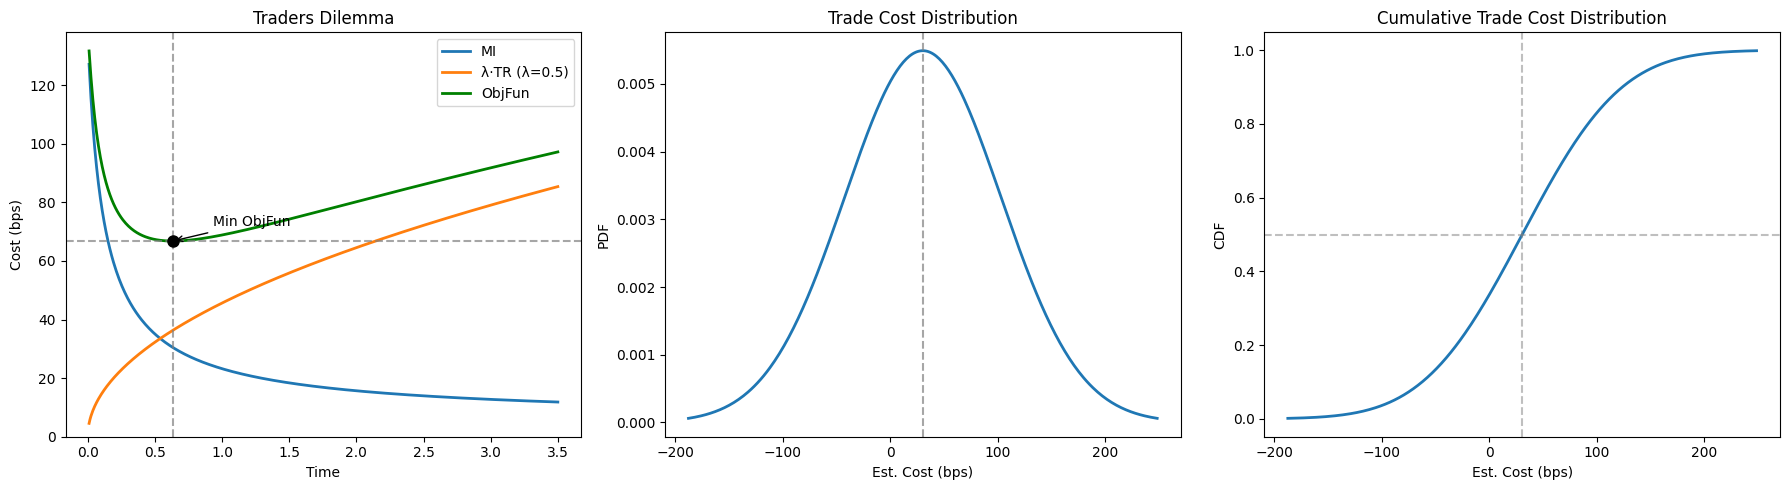

In [14]:
# ✏️ CHANGE THESE
Side       = 1       # +1 = Buy, -1 = Sell
Size       = 0.10
Volatility = 0.25
Lambda     = 0.5     # Risk aversion

# ═══ Optimization ═══
def obj_td(pov):
    t = PovToTime(Size, pov)
    return MI(Size, Volatility, pov) + Lambda * TR(Volatility, t)

res = minimize(obj_td, x0=[0.15], bounds=[(0.01, 0.99)])
opt_pov = res.x[0]
opt_time = PovToTime(Size, opt_pov)
opt_mi = MI(Size, Volatility, opt_pov)
opt_tr = TR(Volatility, opt_time)
opt_obj = opt_mi + Lambda * opt_tr

print(f"Optimal POV  = {opt_pov*100:.2f}%")
print(f"MI           = {opt_mi:.2f} bps")
print(f"TR           = {opt_tr:.2f} bps")
print(f"Trade Time   = {opt_time:.4f} days")
print(f"Obj Function = {opt_obj:.2f} bps")

# ═══ GRAPH: Traders Dilemma ═══
times = np.linspace(0.01, 3.5, 500)
povs  = [TimeToPOV(Size, t) for t in times]
mi_curve  = [MI(Size, Volatility, p) for p in povs]
tr_curve  = [Lambda * TR(Volatility, t) for t in times]
obj_curve = [m + t for m, t in zip(mi_curve, tr_curve)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Traders Dilemma
ax = axes[0]
ax.plot(times, mi_curve, label='MI', linewidth=2)
ax.plot(times, tr_curve, label=f'λ·TR (λ={Lambda})', linewidth=2)
ax.plot(times, obj_curve, label='ObjFun', linewidth=2, color='green')
ax.axvline(opt_time, color='gray', linestyle='--', alpha=0.7)
ax.axhline(opt_obj, color='gray', linestyle='--', alpha=0.7)
ax.plot(opt_time, opt_obj, 'ko', markersize=8)
ax.annotate('Min ObjFun', xy=(opt_time, opt_obj), xytext=(opt_time+0.3, opt_obj+5),
            fontsize=10, arrowprops=dict(arrowstyle='->'))
ax.set_xlabel('Time'); ax.set_ylabel('Cost (bps)'); ax.set_title('Traders Dilemma')
ax.legend(); ax.set_ylim(bottom=0)

# Plot 2: PDF
ax = axes[1]
x_range = np.linspace(opt_mi - 3*opt_tr, opt_mi + 3*opt_tr, 300)
pdf_vals = stats.norm.pdf(x_range, loc=opt_mi, scale=opt_tr)
ax.plot(x_range, pdf_vals, linewidth=2)
ax.axvline(opt_mi, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('Est. Cost (bps)'); ax.set_ylabel('PDF'); ax.set_title('Trade Cost Distribution')

# Plot 3: CDF
ax = axes[2]
cdf_vals = stats.norm.cdf(x_range, loc=opt_mi, scale=opt_tr)
ax.plot(x_range, cdf_vals, linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(opt_mi, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Est. Cost (bps)'); ax.set_ylabel('CDF'); ax.set_title('Cumulative Trade Cost Distribution')

plt.tight_layout()
plt.show()

---
## Section 11 — Minimize Cost Optimization

**When the stock has a price trend (Alpha ≠ 0).**

**Objective:** Minimize `MI + PA` (Expected Cost)

If you're **buying** a stock trending **up** (positive Alpha):
- Trading fast → high MI, low PA (you don't lose much to drift)
- Trading slow → low MI, high PA (the price keeps rising while you wait)

The optimizer finds the trade speed that balances these.

Optimal POV  = 18.48%
MI           = 37.75 bps
PA           = 22.06 bps
TR           = 60.63 bps
Trade Time   = 0.4412 days
Exp Cost     = 59.81 bps


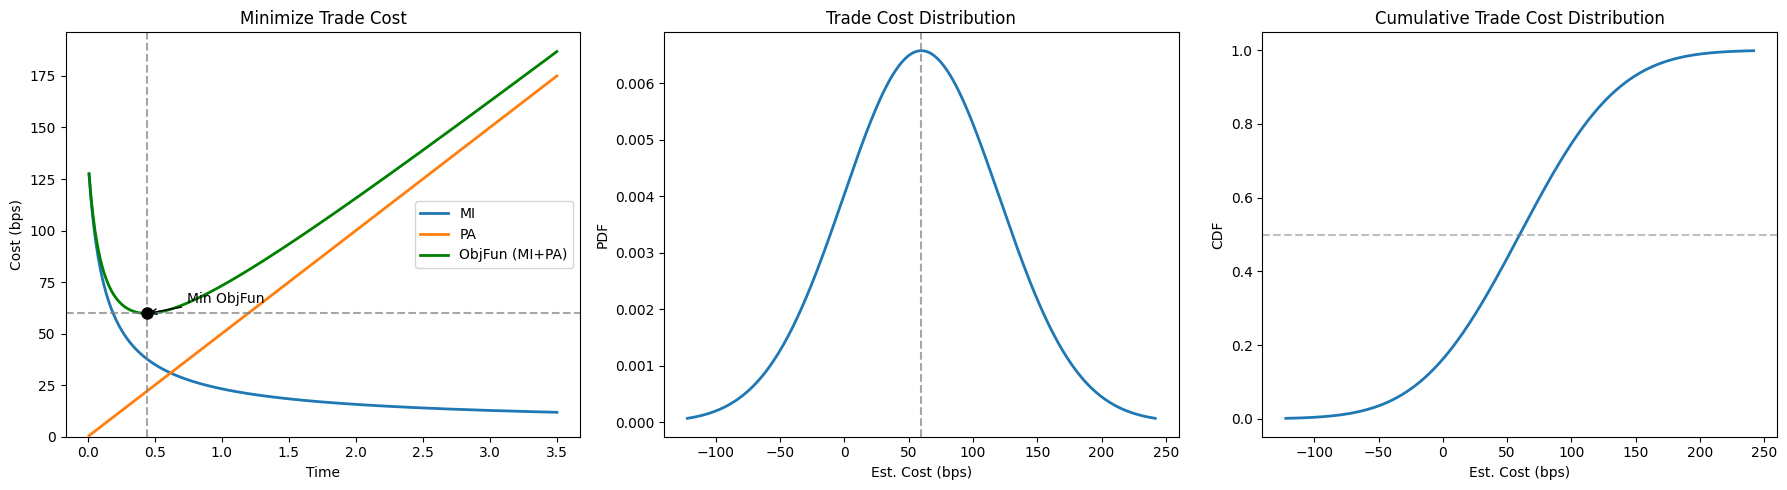

In [15]:
# ✏️ CHANGE THESE
Side       = 1       # +1 = Buy, -1 = Sell
Size       = 0.10
Volatility = 0.25
AlphaBp    = 100     # Price trend in bp/day

# ═══ Optimization ═══
def obj_mc(pov):
    t = PovToTime(Size, pov)
    return MI(Size, Volatility, pov) + PA(Side, AlphaBp, t)

res = minimize(obj_mc, x0=[0.15], bounds=[(0.01, 0.99)])
opt_pov = res.x[0]
opt_time = PovToTime(Size, opt_pov)
opt_mi = MI(Size, Volatility, opt_pov)
opt_pa = PA(Side, AlphaBp, opt_time)
opt_tr = TR(Volatility, opt_time)
opt_obj = opt_mi + opt_pa

print(f"Optimal POV  = {opt_pov*100:.2f}%")
print(f"MI           = {opt_mi:.2f} bps")
print(f"PA           = {opt_pa:.2f} bps")
print(f"TR           = {opt_tr:.2f} bps")
print(f"Trade Time   = {opt_time:.4f} days")
print(f"Exp Cost     = {opt_obj:.2f} bps")

# ═══ GRAPH: Minimize Cost ═══
times = np.linspace(0.01, 3.5, 500)
povs  = [TimeToPOV(Size, t) for t in times]
mi_curve  = [MI(Size, Volatility, p) for p in povs]
pa_curve  = [PA(Side, AlphaBp, t) for t in times]
obj_curve = [m + p for m, p in zip(mi_curve, pa_curve)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(times, mi_curve, label='MI', linewidth=2)
ax.plot(times, pa_curve, label='PA', linewidth=2)
ax.plot(times, obj_curve, label='ObjFun (MI+PA)', linewidth=2, color='green')
ax.axvline(opt_time, color='gray', linestyle='--', alpha=0.7)
ax.axhline(opt_obj, color='gray', linestyle='--', alpha=0.7)
ax.plot(opt_time, opt_obj, 'ko', markersize=8)
ax.annotate('Min ObjFun', xy=(opt_time, opt_obj), xytext=(opt_time+0.3, opt_obj+5),
            fontsize=10, arrowprops=dict(arrowstyle='->'))
ax.set_xlabel('Time'); ax.set_ylabel('Cost (bps)'); ax.set_title('Minimize Trade Cost')
ax.legend(); ax.set_ylim(bottom=0)

ax = axes[1]
x_range = np.linspace(opt_obj - 3*opt_tr, opt_obj + 3*opt_tr, 300)
pdf_vals = stats.norm.pdf(x_range, loc=opt_obj, scale=opt_tr)
ax.plot(x_range, pdf_vals, linewidth=2)
ax.axvline(opt_obj, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('Est. Cost (bps)'); ax.set_ylabel('PDF'); ax.set_title('Trade Cost Distribution')

ax = axes[2]
cdf_vals = stats.norm.cdf(x_range, loc=opt_obj, scale=opt_tr)
ax.plot(x_range, cdf_vals, linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Est. Cost (bps)'); ax.set_ylabel('CDF'); ax.set_title('Cumulative Trade Cost Distribution')

plt.tight_layout()
plt.show()

---
## Section 12 — Price Improvement Optimization

**Goal:** Maximize the probability of beating a price limit (the Bid).

**Objective:** Maximize `t-value = (Bid − MI) / TR`

This is equivalent to minimizing `(MI − Bid) / TR`.

The t-value tells you how many standard deviations away from the bid your expected cost is. Higher t-value = higher probability of executing below the bid price.

**Note:** `Bid` here is in basis points — it's the maximum acceptable cost (e.g., the spread or a limit).

Optimal POV  = 25.36%
MI           = 47.54 bps
TR           = 49.53 bps
Trade Time   = 0.2944 days
t-value      = 1.0592
Prob(cost < Bid) = 85.53%


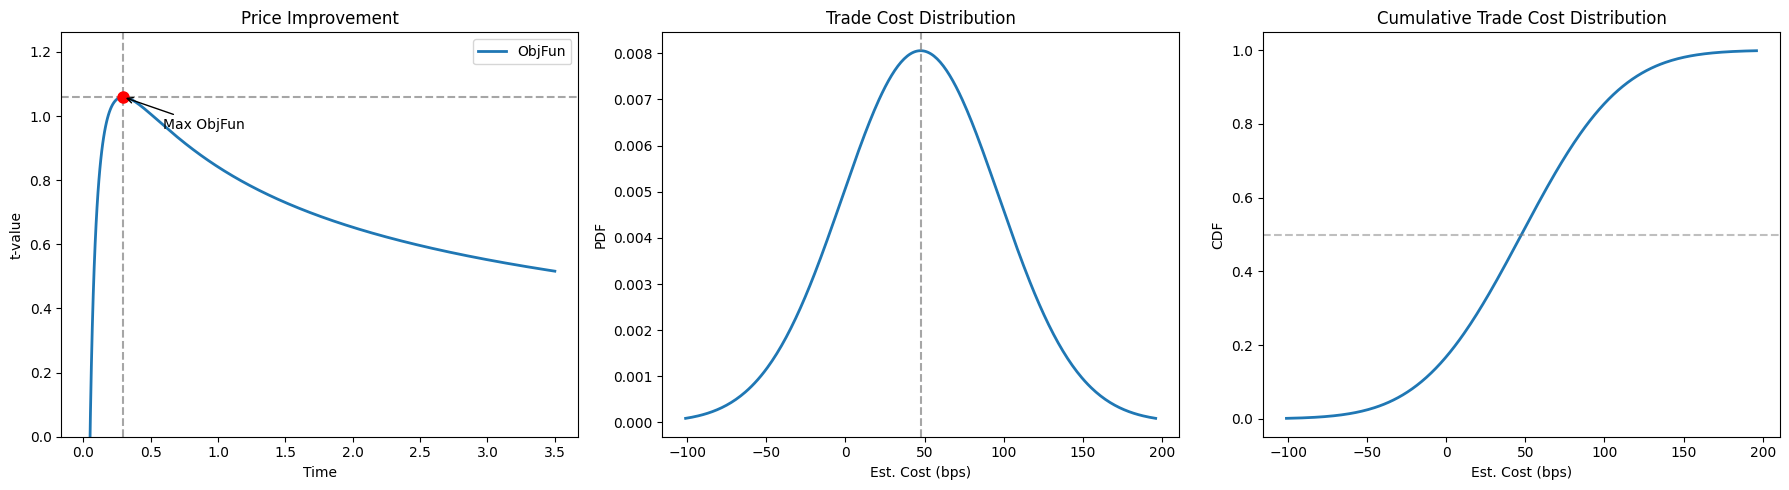

In [16]:
# ✏️ CHANGE THESE
Side       = 1       # +1 = Buy, -1 = Sell
Size       = 0.10
Volatility = 0.25
Bid        = 100     # Max acceptable cost in bps

# ═══ Optimization ═══
# We minimize (MI - Bid)/TR which is equivalent to maximizing (Bid - MI)/TR
def obj_pi(pov):
    t = PovToTime(Size, pov)
    mi = MI(Size, Volatility, pov)
    tr = TR(Volatility, t)
    return (mi - Bid) / tr

res = minimize(obj_pi, x0=[0.25], bounds=[(0.01, 0.99)])
opt_pov = res.x[0]
opt_time = PovToTime(Size, opt_pov)
opt_mi = MI(Size, Volatility, opt_pov)
opt_tr = TR(Volatility, opt_time)
opt_tval = (Bid - opt_mi) / opt_tr  # The t-value (positive = good)

print(f"Optimal POV  = {opt_pov*100:.2f}%")
print(f"MI           = {opt_mi:.2f} bps")
print(f"TR           = {opt_tr:.2f} bps")
print(f"Trade Time   = {opt_time:.4f} days")
print(f"t-value      = {opt_tval:.4f}")
print(f"Prob(cost < Bid) = {stats.norm.cdf(opt_tval)*100:.2f}%")

# ═══ GRAPH: Price Improvement ═══
times = np.linspace(0.01, 3.5, 500)
povs  = [TimeToPOV(Size, t) for t in times]
tvals = []
for t_i, p_i in zip(times, povs):
    mi_i = MI(Size, Volatility, p_i)
    tr_i = TR(Volatility, t_i)
    tvals.append((Bid - mi_i) / tr_i)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(times, tvals, label='ObjFun', linewidth=2)
ax.axvline(opt_time, color='gray', linestyle='--', alpha=0.7)
ax.axhline(opt_tval, color='gray', linestyle='--', alpha=0.7)
ax.plot(opt_time, opt_tval, 'ro', markersize=8)
ax.annotate('Max ObjFun', xy=(opt_time, opt_tval), xytext=(opt_time+0.3, opt_tval-0.1),
            fontsize=10, arrowprops=dict(arrowstyle='->'))
ax.set_xlabel('Time'); ax.set_ylabel('t-value'); ax.set_title('Price Improvement')
ax.legend(); ax.set_ylim(bottom=0)

ax = axes[1]
x_range = np.linspace(opt_mi - 3*opt_tr, opt_mi + 3*opt_tr, 300)
pdf_vals = stats.norm.pdf(x_range, loc=opt_mi, scale=opt_tr)
ax.plot(x_range, pdf_vals, linewidth=2)
ax.axvline(opt_mi, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('Est. Cost (bps)'); ax.set_ylabel('PDF'); ax.set_title('Trade Cost Distribution')

ax = axes[2]
cdf_vals = stats.norm.cdf(x_range, loc=opt_mi, scale=opt_tr)
ax.plot(x_range, cdf_vals, linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Est. Cost (bps)'); ax.set_ylabel('CDF'); ax.set_title('Cumulative Trade Cost Distribution')

plt.tight_layout()
plt.show()

---
## Section 13 — Efficient Trading Frontier

**Concept:** Just like the efficient frontier in portfolio theory (risk vs. return), here we plot **MI vs. TR** for different trade aggressiveness levels.

**Method:** Solve the Traders Dilemma for many values of λ (from very risk-tolerant to very risk-averse). Each λ gives a different optimal (MI, TR) pair.

The resulting curve shows the tradeoff: you can only reduce MI by accepting more TR, and vice versa. Points on the frontier are "efficient" — no free lunch.

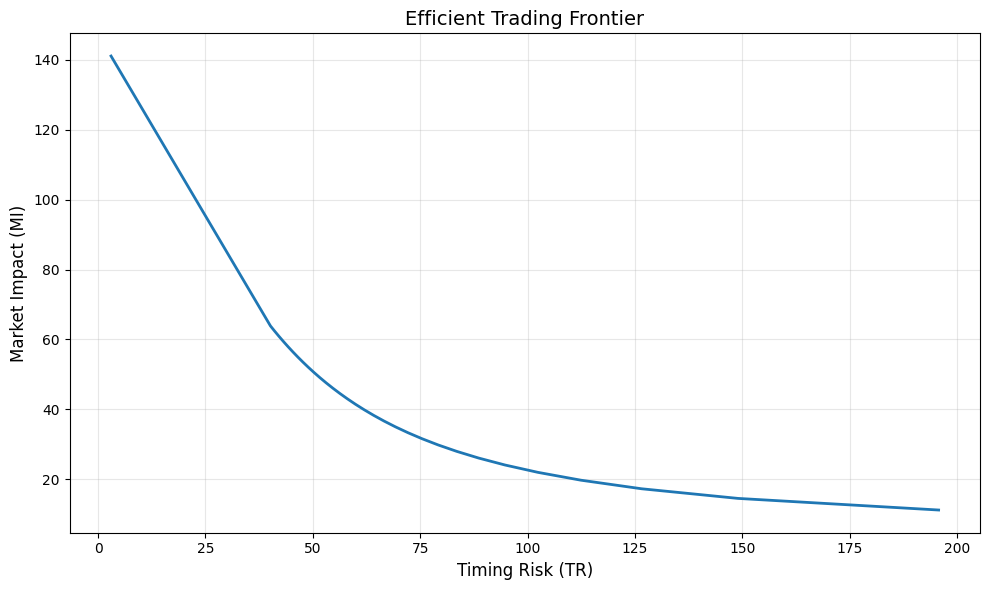


Sample frontier points:
  λ=0.05  →  MI=11.25,  TR=195.70
  λ=0.55  →  MI=33.35,  TR=72.15
  λ=1.05  →  MI=49.08,  TR=51.66
  λ=1.55  →  MI=63.87,  TR=40.14
  λ=2.05  →  MI=141.03,  TR=3.02
  λ=2.55  →  MI=141.03,  TR=3.02


In [17]:
# ✏️ CHANGE THESE
Shares     = 150000
ADV        = 2000000
Size       = Shares / ADV
Volatility = 0.30

# ═══ Sweep λ values ═══
lambdas = np.arange(0.05, 3.01, 0.05)
frontier_mi = []
frontier_tr = []

for lam in lambdas:
    def obj_ef(pov, lam=lam):
        t = PovToTime(Size, pov)
        return MI(Size, Volatility, pov) + lam * TR(Volatility, t)
    
    res = minimize(obj_ef, x0=[0.15], bounds=[(0.01, 0.99)])
    p = res.x[0]
    t = PovToTime(Size, p)
    frontier_mi.append(MI(Size, Volatility, p))
    frontier_tr.append(TR(Volatility, t))

# ═══ GRAPH ═══
plt.figure(figsize=(10, 6))
plt.plot(frontier_tr, frontier_mi, linewidth=2)
plt.xlabel('Timing Risk (TR)', fontsize=12)
plt.ylabel('Market Impact (MI)', fontsize=12)
plt.title('Efficient Trading Frontier', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSample frontier points:")
for i in range(0, len(lambdas), 10):
    print(f"  λ={lambdas[i]:.2f}  →  MI={frontier_mi[i]:.2f},  TR={frontier_tr[i]:.2f}")

---
## Section 14 — Market Impact Constraint

**Problem:** What's the maximum number of shares you can trade in a given time without exceeding a market impact limit?

**Method:** Use root-finding (brentq) to solve `MI(size) = MI_target` for a fixed trade time.

Max Shares = 449120
MI         = 50.0000 bps
Size       = 22.4560%


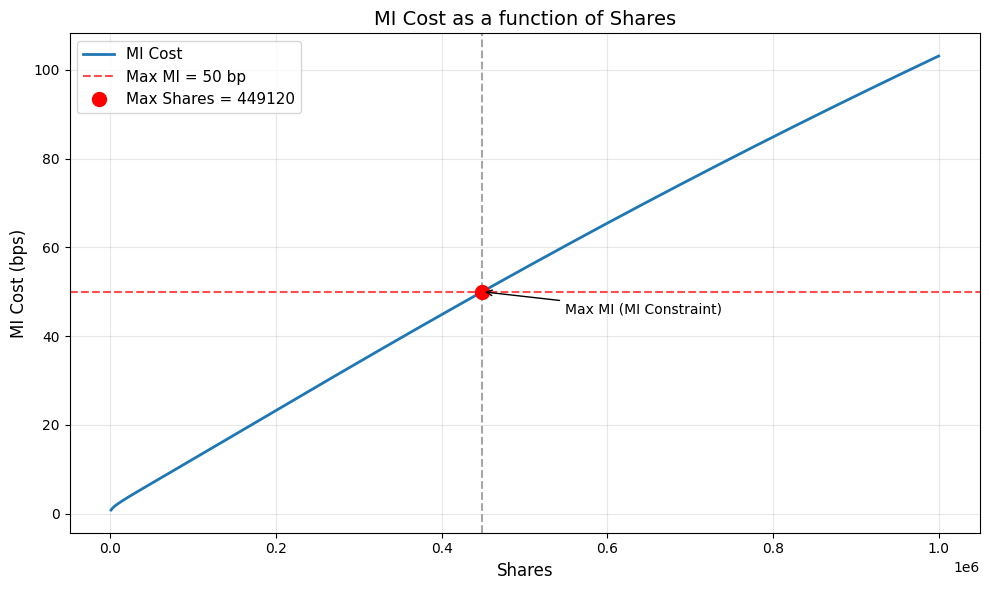

In [18]:
# ✏️ CHANGE THESE
ADV        = 2000000
Volatility = 0.25
MI_target  = 50       # Max allowed MI in bps
TradeTime  = 1.0      # Must finish in this many days

# ═══ Solve ═══
def mi_diff(size):
    pov = TimeToPOV(size, TradeTime)
    return MI(size, Volatility, pov) - MI_target

opt_size = brentq(mi_diff, 0.0001, 1.0)
max_shares = opt_size * ADV
opt_pov = TimeToPOV(opt_size, TradeTime)
actual_mi = MI(opt_size, Volatility, opt_pov)

print(f"Max Shares = {max_shares:.0f}")
print(f"MI         = {actual_mi:.4f} bps")
print(f"Size       = {opt_size*100:.4f}%")

# ═══ GRAPH ═══
share_range = np.linspace(1000, ADV * 0.50, 500)
mi_values = []
for s in share_range:
    sz = s / ADV
    p = TimeToPOV(sz, TradeTime)
    mi_values.append(MI(sz, Volatility, p))

plt.figure(figsize=(10, 6))
plt.plot(share_range, mi_values, linewidth=2, label='MI Cost')
plt.axhline(MI_target, color='red', linestyle='--', alpha=0.7, label=f'Max MI = {MI_target} bp')
plt.axvline(max_shares, color='gray', linestyle='--', alpha=0.7)
plt.plot(max_shares, actual_mi, 'ro', markersize=10, label=f'Max Shares = {max_shares:.0f}')
plt.annotate(f'Max MI (MI Constraint)', xy=(max_shares, actual_mi),
             xytext=(max_shares + ADV*0.05, actual_mi - 5),
             fontsize=10, arrowprops=dict(arrowstyle='->'))
plt.xlabel('Shares', fontsize=12)
plt.ylabel('MI Cost (bps)', fontsize=12)
plt.title('MI Cost as a function of Shares', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Quick Reference — Formula Cheat Sheet

### Post-Trade Formulas
| Measure | Formula | Units |
|---------|---------|-------|
| Paper Return | `side × S × (Pn − Pd)` | $ |
| Portfolio Return | `side × X × (Pn − Pavg) − Fixed` | $ |
| IS Total | `Paper − Portfolio` | $ |
| Delay Cost | `side × S × (P0 − Pd)` | $ |
| Execution Cost | `side × X × (Pavg − P0)` | $ |
| Opportunity Cost | `side × R × (Pn − P0)` | $ |
| Arrival Cost | `side × (Pavg − P0) / P0 × 10000` | bp |
| VWAP Slippage | `side × (Pavg − VWAP) / VWAP × 10000` | bp |
| Benchmark Cost | `side × (Pavg − Bench) / Bench × 10000` | bp |
| Value-Add | `Expected MI − Arrival Cost` | bp |
| Z-Score | `Value-Add / TR` | — |

### Pre-Trade Formulas
| Measure | Formula | Units |
|---------|---------|-------|
| I* | `a1 × Size^a2 × Vol^a3` | bp |
| MI | `I* × [b1 × POV^a4 + (1−b1)]` | bp |
| TR | `Vol × √(1/3 × 1/250 × T) × 10000` | bp |
| PA | `Side × 0.5 × Alpha × T` | bp |
| POV→Time | `Size × (1−POV) / POV` | days |
| Time→POV | `Size / (Size + T)` | — |
| Exp Cost | `MI + PA` | bp |
| Exp Price | `P0 × (1 + Side × ExpCost / 10000)` | $ |

### Optimization Objectives
| Problem | Minimize / Maximize |
|---------|--------------------|
| Traders Dilemma | Minimize `MI + λ·TR` |
| Min Cost | Minimize `MI + PA` |
| Price Improvement | Maximize `(Bid − MI) / TR` |
| Efficient Frontier | Solve Traders Dilemma for λ ∈ [0.05, 3.00] |
| MI Constraint | Solve `MI(size) = target` using root finder |